
# Landmark – AI-Powered Indian Monument Recognition & Travel Guide

An AI-powered web application that identifies 23 Indian monuments from an uploaded image using transfer learning with DenseNet121. The platform provides concise monument information, historical insights, location maps, nearby attractions, and an AI travel guide to help users explore India's cultural heritage.


See `README.md` in this repo for the full project write-up, setup instructions, and results.

**Author:** Harshini Perumal · AIML · 1nt24ai023.harshini@nmit.ac.in

## 1. Setup

In [ ]:
!pip install kagglehub tensorflow matplotlib seaborn scikit-learn -q

In [ ]:
import pandas as pd

## 2. Dataset

[Indian Monuments Image Dataset](https://www.kaggle.com/datasets/danushkumarv/indian-monuments-image-dataset) from Kaggle (downloaded via `kagglehub`) — 23 monument classes with a train/test split shipped by the dataset itself.

In [ ]:
import kagglehub
import os
from collections import Counter

path = kagglehub.dataset_download("danushkumarv/indian-monuments-image-dataset")
print("Dataset stored at:", path)

100%|██████████| 621M/621M [00:09<00:00, 70.4MB/s]

Extracting files...


Dataset stored at: /root/.cache/kagglehub/datasets/danushkumarv/indian-monuments-image-dataset/versions/1


In [ ]:
from collections import Counter
import os

candidate_dirs = []
for root, dirs, files in os.walk(path):
    image_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if image_files and len(dirs) == 0:
        candidate_dirs.append(os.path.dirname(root))

dir_counts = Counter(candidate_dirs)
print("Candidate class-parent directories found:")
for d, cnt in dir_counts.most_common():
    print(f"  {cnt:3d} class folders  ->  {d}")

# The dataset ships its own train/ and test/ split — detect both instead of
# picking just one and later carving a synthetic split out of it.
unique_dirs = list(dir_counts.keys())
train_matches = [d for d in unique_dirs if 'train' in os.path.basename(d).lower()]
test_matches = [d for d in unique_dirs if 'test' in os.path.basename(d).lower()]

TRAIN_DIR = train_matches[0] if train_matches else dir_counts.most_common(1)[0][0]
TEST_DIR = test_matches[0] if test_matches else None

DATA_DIR = TRAIN_DIR  # kept so the dataset-summary cells below don't need changes

print("\nDetected TRAIN_DIR:", TRAIN_DIR)
print("Detected TEST_DIR :", TEST_DIR)

# Print class names in numbered list
class_names = sorted(os.listdir(TRAIN_DIR))

# Drop lotus_temple entirely: too few images (23) and no reliable test data for it
class_names = [c for c in class_names if c != 'lotus_temple']

print("\nClass Names:\n")
for i, cls in enumerate(class_names, start=1):
    print(f"{i:2d}. {cls}")

Candidate class-parent directories found:
   24 class folders  ->  /root/.cache/kagglehub/datasets/danushkumarv/indian-monuments-image-dataset/versions/1/Indian-monuments/images/train
   22 class folders  ->  /root/.cache/kagglehub/datasets/danushkumarv/indian-monuments-image-dataset/versions/1/Indian-monuments/images/test
    2 class folders  ->  /root/.cache/kagglehub/datasets/danushkumarv/indian-monuments-image-dataset/versions/1/Indian-monuments/images/test/Khajuraho

Detected TRAIN_DIR: /root/.cache/kagglehub/datasets/danushkumarv/indian-monuments-image-dataset/versions/1/Indian-monuments/images/train
Detected TEST_DIR : /root/.cache/kagglehub/datasets/danushkumarv/indian-monuments-image-dataset/versions/1/Indian-monuments/images/test

Class Names:

 1. Ajanta Caves
 2. Charar-E- Sharif
 3. Chhota_Imambara
 4. Ellora Caves
 5. Fatehpur Sikri
 6. Gateway of India
 7. Humayun_s Tomb
 8. India gate pics
 9. Khajuraho
10. Sun Temple Konark
11. alai_darwaza
12. alai_minar
13. basilica_

In [ ]:
image_counts = {}

for cls in class_names:
    folder = os.path.join(DATA_DIR, cls)

    count = len([
        f for f in os.listdir(folder)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])

    image_counts[cls] = count

df = pd.DataFrame({
    "Monument": image_counts.keys(),
    "Images": image_counts.values()
})

df

,Monument,Images
0,Ajanta Caves,96
1,Charar-E- Sharif,168
2,Chhota_Imambara,110
3,Ellora Caves,109
4,Fatehpur Sikri,42
5,Gateway of India,203
6,Humayun_s Tomb,166
7,India gate pics,173
8,Khajuraho,44
9,Sun Temple Konark,159


In [ ]:
print("========== DATASET SUMMARY ==========")

print(f"Total Classes          : {len(df)}")
print(f"Total Images           : {df['Images'].sum()}")
print(f"Average Images/Class   : {df['Images'].mean():.2f}")
print(f"Maximum Images/Class   : {df['Images'].max()}")
print(f"Minimum Images/Class   : {df['Images'].min()}")

========== DATASET SUMMARY ==========
Total Classes          : 23
Total Images           : 3643
Average Images/Class   : 158.39
Maximum Images/Class   : 362
Minimum Images/Class   : 42


## 3. Test Set Cleanup

The dataset's test-folder names don't all match the train-folder names, and one folder (`Khajuraho`) ships with stray nested subfolders of misplaced images. Both are fixed here before building the data generators, otherwise `flow_from_directory` would silently give some classes zero test images.

In [ ]:
import os
import re
import shutil



def normalize(name):
    name = name.lower()
    name = re.sub(r'[ _\-]+', ' ', name)
    name = re.sub(r'\b(pics?|images?|photos?)\b', '', name)
    name = re.sub(r'\s+', ' ', name).strip()
    return name

# Define a writable directory for test data
# In Kaggle, use '/kaggle/working/', in Colab, '/content/' is a good choice
WRITABLE_TEST_DIR = os.path.join('/kaggle/working/', os.path.basename(TEST_DIR))

# Copy TEST_DIR contents to the writable location if it hasn't been copied already
if not os.path.exists(WRITABLE_TEST_DIR) or not os.listdir(WRITABLE_TEST_DIR):
    print(f"Copying test data from '{TEST_DIR}' to writable '{WRITABLE_TEST_DIR}'...")
    shutil.copytree(TEST_DIR, WRITABLE_TEST_DIR, dirs_exist_ok=True)
    print("Copy complete.")

# Update TEST_DIR to point to the writable location for subsequent operations
TEST_DIR = WRITABLE_TEST_DIR

train_folders = [f for f in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, f))]
test_folders = [f for f in os.listdir(TEST_DIR) if os.path.isdir(os.path.join(TEST_DIR, f))]

train_norm = {normalize(f): f for f in train_folders}

renamed, unmatched, already_ok = [], [], []

for test_folder in test_folders:
    key = normalize(test_folder)
    if key in train_norm:
        target_name = train_norm[key]
        if test_folder == target_name:
            already_ok.append(test_folder)
        else:
            src = os.path.join(TEST_DIR, test_folder)
            dst = os.path.join(TEST_DIR, target_name)
            if os.path.exists(dst):
                print(f"  SKIP: target '{target_name}' already exists, can't rename '{test_folder}' onto it")
            else:
                os.rename(src, dst)
                renamed.append((test_folder, target_name))
    else:
        unmatched.append(test_folder)

print(f"Already matching train names : {len(already_ok)}")
print(f"Renamed to match train names : {len(renamed)}")
for old, new in renamed:
    print(f"   '{old}'  ->  '{new}'")

if unmatched:
    print(f"\n⚠️  {len(unmatched)} TEST_DIR folders could not be matched to any TRAIN_DIR class (left as-is):")
    for u in unmatched:
        print(f"   {u!r}")

# Re-list TEST_DIR after renames to get accurate current folders
current_test_folders = os.listdir(TEST_DIR)
missing_in_test = sorted(set(class_names) - set(current_test_folders))
if missing_in_test:
    print(f"\n⚠️  {len(missing_in_test)} TRAIN_DIR classes still have NO matching folder in TEST_DIR after renaming:")
    for m in missing_in_test:
        print(f"   {m!r}")
else:
    print("\n✅ Every train class now has a matching folder name in TEST_DIR.")


Copying test data from '/root/.cache/kagglehub/datasets/danushkumarv/indian-monuments-image-dataset/versions/1/Indian-monuments/images/test' to writable '/kaggle/working/test'...
Copy complete.
Already matching train names : 22
Renamed to match train names : 2
   'Hawa mahal'  ->  'hawa mahal pics'
   'India_gate'  ->  'India gate pics'

✅ Every train class now has a matching folder name in TEST_DIR.


### Clean up stray nested folders inside TEST_DIR (e.g. Khajuraho)

The Khajuraho test folder ships with extra subfolders nested inside it (other monuments'
images misplaced there). `flow_from_directory` won't recurse into them so they don't
corrupt training directly, but they're junk data sitting in the wrong place and can
confuse file counts / the duplicate-check cell below. This removes any subfolder found
inside a class folder, keeping only the image files that belong directly in it.

In [ ]:

import os
import shutil

removed_summary = {}

for cls in os.listdir(TEST_DIR):
    cls_path = os.path.join(TEST_DIR, cls)
    if not os.path.isdir(cls_path):
        continue

    nested_dirs = [
        d for d in os.listdir(cls_path)
        if os.path.isdir(os.path.join(cls_path, d))
    ]

    if nested_dirs:
        removed_summary[cls] = []
        for d in nested_dirs:
            nested_path = os.path.join(cls_path, d)
            img_count = len([
                f for f in os.listdir(nested_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png', '.jfif'))
            ])
            removed_summary[cls].append((d, img_count))
            shutil.rmtree(nested_path)

if removed_summary:
    print("Removed stray nested folders:")
    for cls, dirs in removed_summary.items():
        print(f"  {cls}:")
        for d, cnt in dirs:
            print(f"     removed '{d}'  ({cnt} images)")
else:
    print("No stray nested folders found inside TEST_DIR class folders.")

# Sanity check: confirm Khajuraho test folder is now flat
khaj_path = os.path.join(TEST_DIR, "Khajuraho")
if os.path.isdir(khaj_path):
    remaining = os.listdir(khaj_path)
    subdirs_left = [d for d in remaining if os.path.isdir(os.path.join(khaj_path, d))]
    imgs_left = [f for f in remaining if f.lower().endswith(('.jpg', '.jpeg', '.png', '.jfif'))]
    print(f"\nKhajuraho test folder now has {len(imgs_left)} images, {len(subdirs_left)} subfolders left.")


Removed stray nested folders:
  Khajuraho:
     removed 'lotus_temple'  (30 images)
     removed 'mysore_palace'  (29 images)
     removed 'Chhota_Imambara'  (30 images)

Khajuraho test folder now has 44 images, 0 subfolders left.


## 4. Data Pipeline — Generators & Augmentation

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import preprocess_input

IMG_SIZE = (224, 224)
BATCH = 32

# Training generator: augmentation + DenseNet's own preprocessing
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    validation_split=0.2
)

# Validation generator: SAME split, but NO augmentation (only preprocessing)
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

# Test generator: the dataset's OWN held-out test folder — no split, no augmentation
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH, classes=class_names,
    class_mode='categorical', subset='training', shuffle=True, seed=42
)

val_gen = val_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH, classes=class_names,
    class_mode='categorical', subset='validation', shuffle=False, seed=42
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH, classes=class_names,
    class_mode='categorical', shuffle=False
)

NUM_CLASSES = train_gen.num_classes
class_names = sorted(train_gen.class_indices.keys())
print("Number of classes:", NUM_CLASSES)
print("Classes:", class_names)
print("Test images:", test_gen.samples)

Found 2923 images belonging to 23 classes.
Found 720 images belonging to 23 classes.
Found 990 images belonging to 23 classes.
Number of classes: 23
Classes: ['Ajanta Caves', 'Charar-E- Sharif', 'Chhota_Imambara', 'Ellora Caves', 'Fatehpur Sikri', 'Gateway of India', 'Humayun_s Tomb', 'India gate pics', 'Khajuraho', 'Sun Temple Konark', 'alai_darwaza', 'alai_minar', 'basilica_of_bom_jesus', 'charminar', 'golden temple', 'hawa mahal pics', 'iron_pillar', 'jamali_kamali_tomb', 'mysore_palace', 'qutub_minar', 'tajmahal', 'tanjavur temple', 'victoria memorial']
Test images: 990


In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

train_classes = train_gen.classes
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_classes),
    y=train_classes
)
class_weights = dict(enumerate(class_weights_array))

print("="*50)
print("DATASET INFORMATION")
print("="*50)
print(f"Training Images   : {train_gen.samples}")
print(f"Validation Images : {val_gen.samples}")
print(f"Test Images       : {test_gen.samples}")
print(f"Total Images      : {train_gen.samples + val_gen.samples + test_gen.samples}")
print(f"Number of Classes : {NUM_CLASSES}")
print(f"Batch Size        : {BATCH}")
print(f"Image Size        : {IMG_SIZE}")

print("\nClass weights (balanced):")
for i, cls in enumerate(class_names):
    print(f"  {cls:25s}: {class_weights[i]:.3f}")

DATASET INFORMATION
Training Images   : 2923
Validation Images : 720
Test Images       : 990
Total Images      : 4633
Number of Classes : 23
Batch Size        : 32
Image Size        : (224, 224)

Class weights (balanced):
  Ajanta Caves             : 1.650
  Charar-E- Sharif         : 0.941
  Chhota_Imambara          : 1.444
  Ellora Caves             : 1.444
  Fatehpur Sikri           : 3.738
  Gateway of India         : 0.780
  Humayun_s Tomb           : 0.956
  India gate pics          : 0.914
  Khajuraho                : 3.530
  Sun Temple Konark        : 0.993
  alai_darwaza             : 2.269
  alai_minar               : 1.135
  basilica_of_bom_jesus    : 1.589
  charminar                : 0.743
  golden temple            : 0.756
  hawa mahal pics          : 0.794
  iron_pillar              : 0.629
  jamali_kamali_tomb       : 0.770
  mysore_palace            : 1.717
  qutub_minar              : 0.438
  tajmahal                 : 0.847
  tanjavur temple          : 1.115
  victor

### Sample of Augmented Training Images

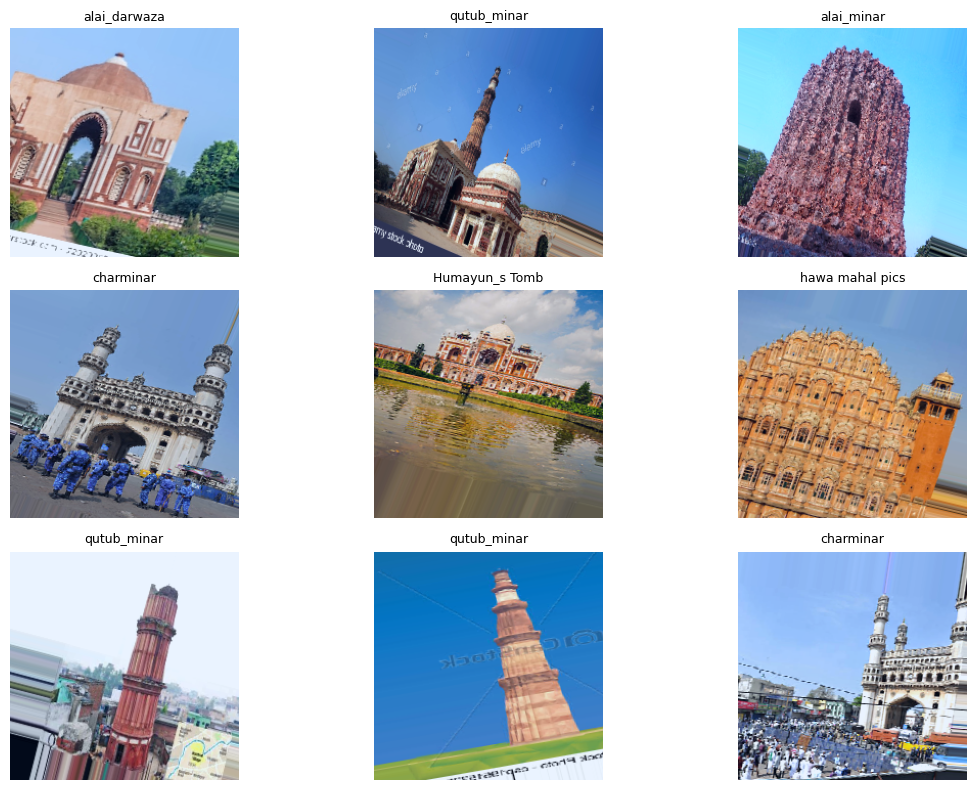

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(train_gen)
plt.figure(figsize=(12, 8))
for i in range(min(9, len(images))):
    plt.subplot(3, 3, i+1)
    img = images[i]
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)  # rescale for display only
    plt.imshow(img)
    label_idx = labels[i].argmax()
    plt.title(class_names[label_idx], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

## 5. Model — DenseNet121 Transfer Learning

ImageNet-pretrained DenseNet121 backbone with a custom classification head (GlobalAveragePooling → Dense(512) → Dense(256) → softmax), trained in stages: first with the backbone frozen, then with the top of the backbone unfrozen for fine-tuning.

In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Load DenseNet121
base = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze backbone for stage 1
base.trainable = False

# Stronger classification head
x = GlobalAveragePooling2D()(base.output)
x = Dense(512, activation='relu', kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

model.summary()

### Stage 1 — Train the Classification Head (backbone frozen)

In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_densenet121_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 844ms/step - accuracy: 0.2676 - loss: 3.1814
Epoch 1: val_accuracy improved from None to 0.70556, saving model to best_densenet121_model.keras

Epoch 1: finished saving model to best_densenet121_model.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.4283 - loss: 2.4723 - val_accuracy: 0.7056 - val_loss: 1.6073 - learning_rate: 0.0010
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 670ms/step - accuracy: 0.6884 - loss: 1.6040
Epoch 2: val_accuracy improved from 0.70556 to 0.85278, saving model to best_densenet121_model.keras

Epoch 2: finished saving model to best_densenet121_model.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 68s 742ms/step - accuracy: 0.7229 - loss: 1.5525 - val_accuracy: 0.8528 - val_loss: 1.2220 - learning_rate: 0.0010
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 682ms/step - accuracy: 0.7558 - loss: 1.4581
Epoch 3: val_accuracy improved from 0.85278 to 0.88472, saving model to best_densenet121_model.keras

Epoch 3: finished saving model 

### Stage 2 — Fine-tune the Top of the Backbone

In [ ]:
base.trainable = True

# Unfreeze more of the backbone than before (DenseNet121 has ~427 layers)
for layer in base.layers[:-100]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

callbacks_ft = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_densenet121_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-8,
        verbose=1
    )
]

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    class_weight=class_weights,
    callbacks=callbacks_ft
)

Epoch 1/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 992ms/step - accuracy: 0.8778 - loss: 1.1184
Epoch 1: val_accuracy improved from None to 0.93056, saving model to best_densenet121_model.keras

Epoch 1: finished saving model to best_densenet121_model.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - accuracy: 0.8738 - loss: 1.1195 - val_accuracy: 0.9306 - val_loss: 1.0066 - learning_rate: 1.0000e-05
Epoch 2/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 679ms/step - accuracy: 0.8952 - loss: 1.0968
Epoch 2: val_accuracy did not improve from 0.93056
92/92 ━━━━━━━━━━━━━━━━━━━━ 68s 736ms/step - accuracy: 0.8915 - loss: 1.0847 - val_accuracy: 0.9250 - val_loss: 1.0062 - learning_rate: 1.0000e-05
Epoch 3/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 683ms/step - accuracy: 0.9025 - loss: 1.0441
Epoch 3: val_accuracy did not improve from 0.93056
92/92 ━━━━━━━━━━━━━━━━━━━━ 73s 795ms/step - accuracy: 0.9032 - loss: 1.0553 - val_accuracy: 0.9292 - val_loss: 1.0032 - learning_rate: 1.0000e-05
Epoch 4/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 6

## 6. Results — Stage 1 + 2

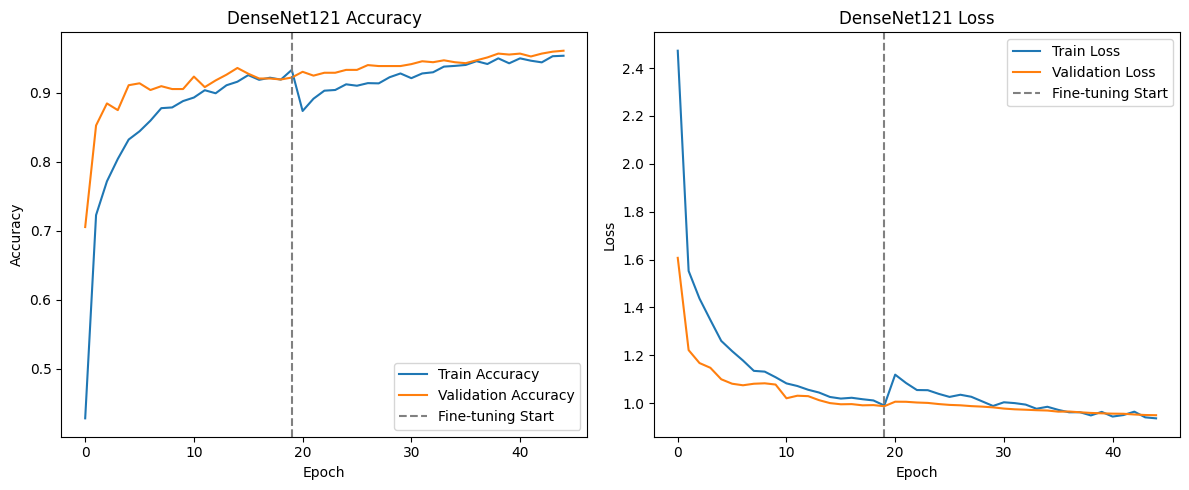

In [ ]:
import matplotlib.pyplot as plt

def combine_history(h1, h2, key):
    return h1.history[key] + h2.history[key]

acc = combine_history(history1, history2, 'accuracy')
val_acc = combine_history(history1, history2, 'val_accuracy')
loss = combine_history(history1, history2, 'loss')
val_loss = combine_history(history1, history2, 'val_loss')

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(
    x=len(history1.history['accuracy'])-1,
    color='gray',
    linestyle='--',
    label='Fine-tuning Start'
)
plt.title("DenseNet121 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.axvline(
    x=len(history1.history['loss'])-1,
    color='gray',
    linestyle='--',
    label='Fine-tuning Start'
)
plt.title("DenseNet121 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig("densenet121_training_curves.png", dpi=150)
plt.show()

### Final Evaluation

In [ ]:
from tensorflow.keras.models import load_model

# Load the best checkpoint (highest val_accuracy across both training phases)
model = load_model("best_densenet121_model.keras")

val_loss_final, val_acc_final = model.evaluate(val_gen)
print(f"Final Validation Accuracy : {val_acc_final*100:.2f}%")
print(f"Final Validation Loss     : {val_loss_final:.4f}")

test_loss_final, test_acc_final = model.evaluate(test_gen)
print(f"\nFinal Test Accuracy       : {test_acc_final*100:.2f}%")
print(f"Final Test Loss           : {test_loss_final:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 32s 668ms/step - accuracy: 0.9611 - loss: 0.9502
Final Validation Accuracy : 96.11%
Final Validation Loss     : 0.9502
31/31 ━━━━━━━━━━━━━━━━━━━━ 24s 769ms/step - accuracy: 0.9586 - loss: 0.9346

Final Test Accuracy       : 95.86%
Final Test Loss           : 0.9346


### Classification Report

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

test_gen.reset()
pred_probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_gen.classes

# Only report on classes that actually have test images (avoids a
# sklearn error/blank rows for the 0-support classes flagged above)
unique_test_labels = np.unique(y_true)
target_names_for_report = [class_names[i] for i in unique_test_labels]

dropped = [class_names[i] for i in range(NUM_CLASSES) if i not in unique_test_labels]


report = classification_report(y_true, y_pred, labels=unique_test_labels, target_names=target_names_for_report, digits=3)
print(report)

with open("densenet121_classification_report.txt", "w") as f:
    f.write(report)


31/31 ━━━━━━━━━━━━━━━━━━━━ 35s 721ms/step
                       precision    recall  f1-score   support

         Ajanta Caves      1.000     0.968     0.984        31
     Charar-E- Sharif      1.000     1.000     1.000        34
      Chhota_Imambara      0.938     1.000     0.968        30
         Ellora Caves      1.000     1.000     1.000        34
       Fatehpur Sikri      1.000     1.000     1.000        42
     Gateway of India      1.000     1.000     1.000        30
       Humayun_s Tomb      1.000     1.000     1.000        30
      India gate pics      1.000     1.000     1.000        45
            Khajuraho      0.978     1.000     0.989        44
    Sun Temple Konark      1.000     0.975     0.987        40
         alai_darwaza      1.000     1.000     1.000        36
           alai_minar      0.972     1.000     0.986        35
basilica_of_bom_jesus      0.935     0.967     0.951        30
            charminar      0.500     1.000     0.667         1
        gold

### Confusion Matrix

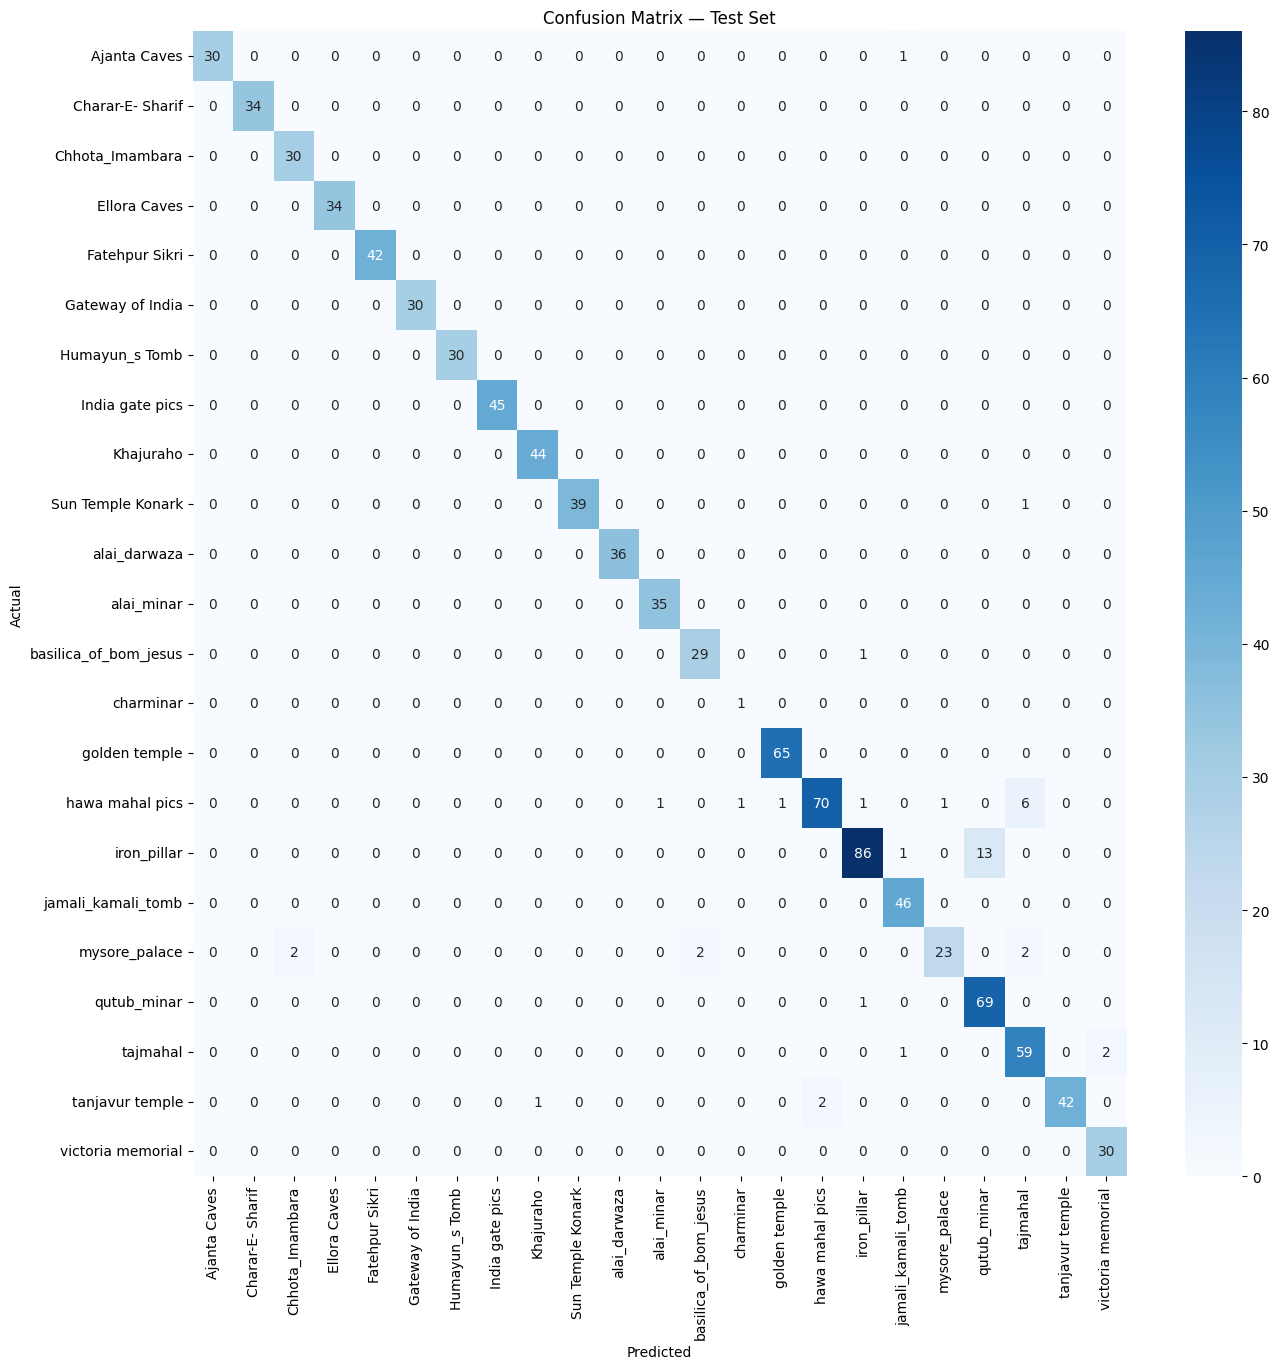

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(max(10, NUM_CLASSES * 0.6), max(8, NUM_CLASSES * 0.6)))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Test Set')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('densenet121_confusion_matrix.png', dpi=150)
plt.show()

## Improving performance further

The cells below are additions on top of the fixes above (they don't change anything before this point):

1. **Train/test duplicate check** — this specific Kaggle dataset is known to have overlapping images between its `train/` and `test/` folders. If the same (or a near-identical) photo is in both, your test accuracy is inflated by memorization, not generalization. This cell flags exact duplicates by file hash.
2. **Test-Time Augmentation (TTA)** — averages predictions over several augmented views of each test image. Usually a free +1-3% accuracy bump with no retraining.
3. **A third, more careful fine-tuning stage** — cosine-decay LR instead of ReduceLROnPlateau, and unfreezes the whole backbone. Optional — only run it if stages 1-2 above are still underfitting (val_accuracy noticeably below train_accuracy) or the loss curves are still trending down.
4. **Focal loss** — a drop-in replacement for `class_weight` when the imbalance is severe; keeps easy classes from swamping gradient updates.


### Train/Test Duplicate-Image Check

### Test-Time Augmentation (TTA)

In [ ]:

import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import preprocess_input
from sklearn.metrics import classification_report

N_TTA = 5  # number of augmented passes to average (1 = no augmentation, just the base prediction)

tta_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
)

all_probs = np.zeros((test_gen.samples, NUM_CLASSES), dtype=np.float64)

# Pass 1: clean, no-augmentation prediction (same as the single-pass report above)
test_gen.reset()
all_probs += model.predict(test_gen, verbose=1)

# Passes 2..N_TTA: augmented predictions on the same file order
for t in range(1, N_TTA):
    tta_gen = tta_datagen.flow_from_directory(
        TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH, classes=class_names,
        class_mode='categorical', shuffle=False
    )
    all_probs += model.predict(tta_gen, verbose=1)
    print(f"TTA pass {t+1}/{N_TTA} done")

avg_probs = all_probs / N_TTA
y_pred_tta = np.argmax(avg_probs, axis=1)
y_true = test_gen.classes

unique_test_labels = np.unique(y_true)
target_names_for_report = [class_names[i] for i in unique_test_labels]

print("\n===== Classification report WITH test-time augmentation =====")
report_tta = classification_report(y_true, y_pred_tta, labels=unique_test_labels, target_names=target_names_for_report, digits=3)
print(report_tta)

with open("densenet121_classification_report_tta.txt", "w") as f:
    f.write(report_tta)


31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 288ms/step
Found 990 images belonging to 23 classes.
31/31 ━━━━━━━━━━━━━━━━━━━━ 18s 569ms/step
TTA pass 2/5 done
Found 990 images belonging to 23 classes.
31/31 ━━━━━━━━━━━━━━━━━━━━ 19s 573ms/step
TTA pass 3/5 done
Found 990 images belonging to 23 classes.
31/31 ━━━━━━━━━━━━━━━━━━━━ 19s 604ms/step
TTA pass 4/5 done
Found 990 images belonging to 23 classes.
31/31 ━━━━━━━━━━━━━━━━━━━━ 18s 577ms/step
TTA pass 5/5 done

===== Classification report WITH test-time augmentation =====
                       precision    recall  f1-score   support

         Ajanta Caves      1.000     1.000     1.000        31
     Charar-E- Sharif      1.000     1.000     1.000        34
      Chhota_Imambara      0.933     0.933     0.933        30
         Ellora Caves      1.000     1.000     1.000        34
       Fatehpur Sikri      1.000     0.976     0.988        42
     Gateway of India      0.968     1.000     0.984        30
       Humayun_s Tomb      1.000     1.000    

###  focal loss instead of `class_weight`

Drop this in place of the `loss=` argument in any `model.compile(...)` call above if some classes are still under-recalled after class weighting. Focal loss down-weights easy, already-confident examples so the model keeps learning from the hard/rare classes instead of coasting on the common ones.

In [ ]:
base.trainable = True
for layer in base.layers:
    layer.trainable = True

steps_per_epoch = train_gen.samples // BATCH
EPOCHS_STAGE3 = 15

cosine_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=5e-6,
    decay_steps=steps_per_epoch * EPOCHS_STAGE3,
    alpha=0.05,
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=cosine_schedule),
    loss=categorical_focal_loss(gamma=2.0, alpha=0.25, label_smoothing=0.1),
    metrics=['accuracy']
)

callbacks_ft3 = [
    EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_densenet121_model_v2_focal.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
]

history3 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_STAGE3,
    callbacks=callbacks_ft3
    # no class_weight here -- focal loss replaces it
)

model.save("densenet121_landmark_model_v2_focal.keras")
print("Saved as v2 (focal loss). Comparing against test set now...")

# --- Re-evaluate on test set, compare against v1 ---
test_gen.reset()
v2_test_loss, v2_test_acc = model.evaluate(test_gen)
print(f"v2 (focal) Test Accuracy : {v2_test_acc*100:.2f}%")
print(f"v1 (Stage 1-2) Test Accuracy was : {test_acc_final*100:.2f}%")

if v2_test_acc > test_acc_final:
    print("v2 improved -- use densenet121_landmark_model_v2_focal.keras for the frontend.")
else:
    print("v2 did NOT improve -- stick with densenet121_landmark_model.keras (v1) for the frontend.")

# --- Full classification report for v2, for a side-by-side look ---
pred_probs_v2 = model.predict(test_gen, verbose=1)
y_pred_v2 = np.argmax(pred_probs_v2, axis=1)
y_true_v2 = test_gen.classes
unique_labels_v2 = np.unique(y_true_v2)
target_names_v2 = [class_names[i] for i in unique_labels_v2]
print(classification_report(y_true_v2, y_pred_v2, labels=unique_labels_v2, target_names=target_names_v2, digits=3))


Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9625 - loss: 0.0926
Epoch 1: val_accuracy improved from None to 0.96111, saving model to best_densenet121_model_v2_focal.keras

Epoch 1: finished saving model to best_densenet121_model_v2_focal.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - accuracy: 0.9589 - loss: 0.0955 - val_accuracy: 0.9611 - val_loss: 0.1001
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 677ms/step - accuracy: 0.9551 - loss: 0.0966
Epoch 2: val_accuracy did not improve from 0.96111
92/92 ━━━━━━━━━━━━━━━━━━━━ 69s 742ms/step - accuracy: 0.9548 - loss: 0.0978 - val_accuracy: 0.9597 - val_loss: 0.0991
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 683ms/step - accuracy: 0.9467 - loss: 0.0995
Epoch 3: val_accuracy did not improve from 0.96111
92/92 ━━━━━━━━━━━━━━━━━━━━ 68s 741ms/step - accuracy: 0.9542 - loss: 0.0971 - val_accuracy: 0.9611 - val_loss: 0.0989
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 682ms/step - accuracy: 0.9539 - loss: 0.0981
Epoch 4: val_accuracy did

### Results — Stage 3 + Focal Loss

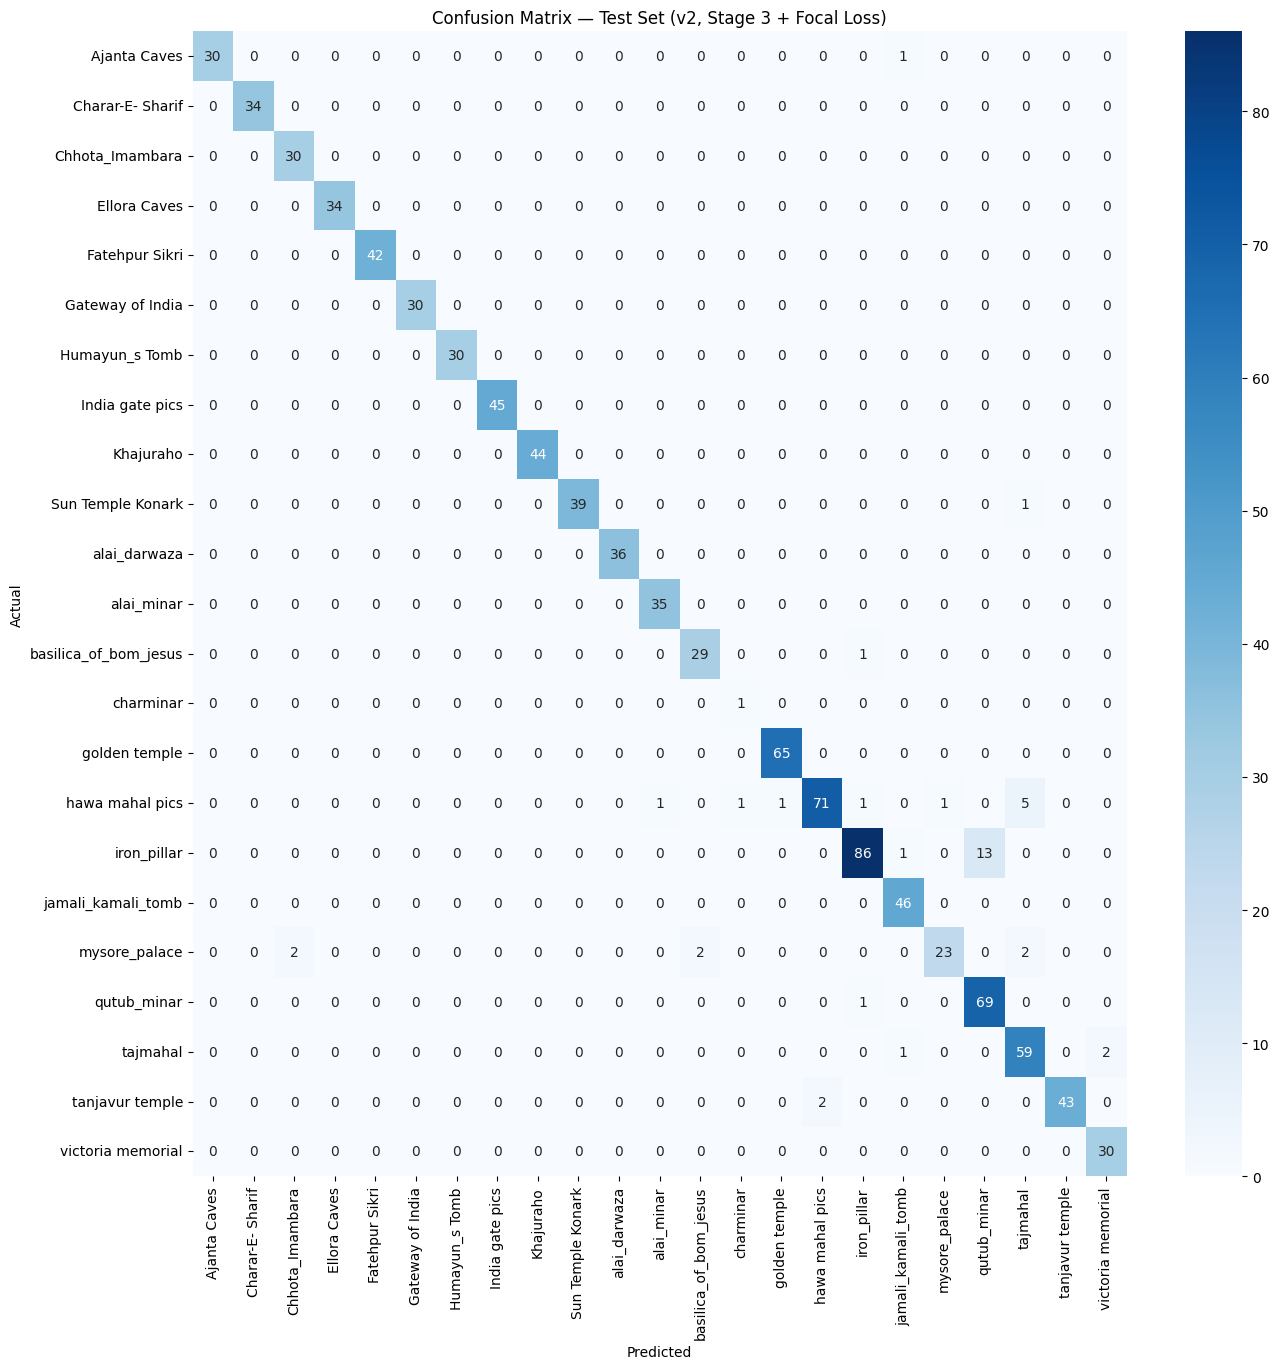

In [ ]:
# --- Confusion matrix for v2 (focal loss) ---
import seaborn as sns

cm_v2 = confusion_matrix(y_true_v2, y_pred_v2)

plt.figure(figsize=(max(10, len(target_names_v2) * 0.6), max(8, len(target_names_v2) * 0.6)))
sns.heatmap(
    cm_v2, annot=True, fmt='d', cmap='Blues',
    xticklabels=target_names_v2, yticklabels=target_names_v2
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Test Set (v2, Stage 3 + Focal Loss)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('densenet121_v2_confusion_matrix.png', dpi=150)
plt.show()

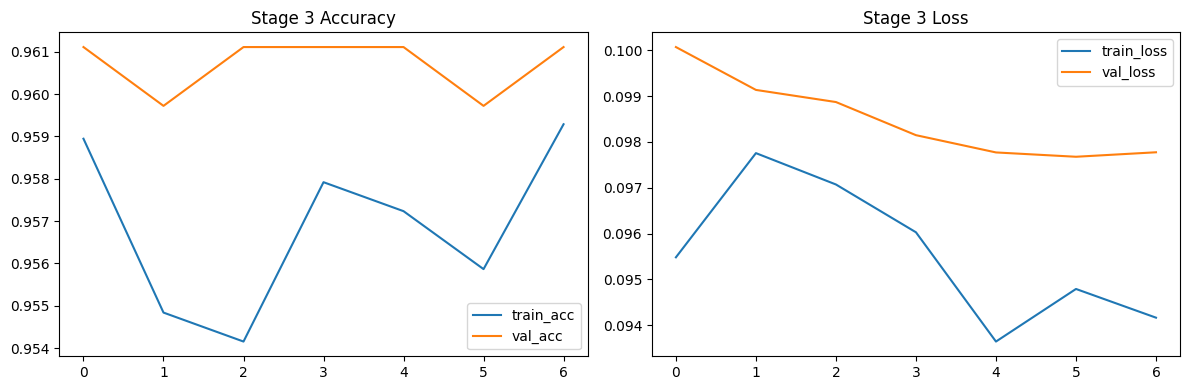

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history3.history['accuracy'], label='train_acc')
plt.plot(history3.history['val_accuracy'], label='val_acc')
plt.title('Stage 3 Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history3.history['loss'], label='train_loss')
plt.plot(history3.history['val_loss'], label='val_loss')
plt.title('Stage 3 Loss')
plt.legend()
plt.tight_layout()
plt.savefig('densenet121_v2_stage3_curves.png', dpi=150)
plt.show()

## Save the FINAL model to Google Drive


Compares v1 (Stage 1-2) vs v2 (Stage 3 + focal) test accuracy and saves whichever one actually
won -- so Drive always ends up with your best model, not just whichever was trained most recently.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
from tensorflow.keras.models import load_model as _load_model

save_dir = "/content/drive/MyDrive/SIC_Project_model1"
os.makedirs(save_dir, exist_ok=True)

if 'v2_test_acc' in globals() and 'test_acc_final' in globals():
    if v2_test_acc > test_acc_final:

        final_model = model
        print(f"v2 (focal) wins: {v2_test_acc*100:.2f}% > v1's {test_acc_final*100:.2f}% -- using in-memory v2 model.")
    else:
        winner_path = "densenet121_landmark_model.keras"
        final_model = _load_model(winner_path)
        print(f"v1 (Stage 1-2) wins: {test_acc_final*100:.2f}% >= v2's {v2_test_acc*100:.2f}% -- loading v1 from disk.")
elif 'test_acc_final' in globals():
    winner_path = "densenet121_landmark_model.keras"
    final_model = _load_model(winner_path)
    print("Stage 3 + focal loss cell wasn't run -- saving v1 (Stage 1-2) model.")
else:
    raise RuntimeError("No trained model found in memory. Run the training cells above first.")


final_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

final_dest = os.path.join(save_dir, "densenet121_landmark_model_FINAL.keras")
final_model.save(final_dest)

print(f"\n✅ Final model saved to Drive: {final_dest}")
print("This is the file to load in the frontend.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
v2 (focal) wins: 96.06% > v1's 95.86% -- using in-memory v2 model.

✅ Final model saved to Drive: /content/drive/MyDrive/SIC_Project_model1/densenet121_landmark_model_FINAL.keras
This is the file to load in the frontend.


## 9. Export Class Names (for inference / frontend)

In [ ]:
import json

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

from google.colab import files
files.download("class_names.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>